# SignSpeech — Member 1: Data Pipeline
**Goal:** Load the WLASL dataset, extract fixed-length frame sequences from each video,
and deliver a clean PyTorch `DataLoader` that M3 (CNN encoder) can consume directly.

**Decisions baked in:**
- JSON source: `nslt_100.json` → 100 word classes
- Frames per clip: T = 32 (uniform sampling)
- Frame size: 224 × 224 (full frame, no bbox crop — M2 handles hand detection)
- Split strategy: use the `split` field already in the JSON (signer-aware)
- Missing videos: skip silently

**Output delivered to team:**
- `train_loader`, `val_loader`, `test_loader` — ready-to-use PyTorch DataLoaders
- `word_to_idx` / `idx_to_word` — label mapping saved to `label_map.json`
- EDA summary — class distribution, video stats, missing video count

## Step 0 — Install & import libraries

In [1]:
# opencv-python is pre-installed on Kaggle; confirm other imports work
import os
import json
import random
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Reproducibility — fix all random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('All imports OK')
print(f'PyTorch version : {torch.__version__}')
print(f'OpenCV  version : {cv2.__version__}')

All imports OK
PyTorch version : 2.10.0+cu128
OpenCV  version : 4.13.0


## Step 1 — Configure paths
**If running on Kaggle:** set `KAGGLE = True` and attach the WLASL dataset.
The dataset will appear at `/kaggle/input/wlasl-video/`.

**If running locally:** set `KAGGLE = False` and point `LOCAL_ROOT` to
the folder that contains `videos/`, `nslt_100.json`, and `missing.txt`.

In [2]:
# ── EDIT THESE TWO LINES ONLY ──────────────────────────────────────────────
KAGGLE     = True                       # True when running on Kaggle
LOCAL_ROOT = r'C:\path\to\your\dataset'    # ignored if KAGGLE=True
# ───────────────────────────────────────────────────────────────────────────

if KAGGLE:
    ROOT       = Path('/kaggle/input/datasets/risangbaskoro/wlasl-processed')
else:
    ROOT       = Path(LOCAL_ROOT)

VIDEO_DIR   = ROOT / 'videos'
JSON_PATH   = ROOT / 'nslt_100.json'
MISSING_TXT = ROOT / 'missing.txt'
OUTPUT_DIR  = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Verify paths exist
for p in [VIDEO_DIR, JSON_PATH, MISSING_TXT]:
    status = '✓' if p.exists() else '✗  NOT FOUND'
    print(f'{status}  {p}')

✓  /kaggle/input/datasets/risangbaskoro/wlasl-processed/videos
✓  /kaggle/input/datasets/risangbaskoro/wlasl-processed/nslt_100.json
✓  /kaggle/input/datasets/risangbaskoro/wlasl-processed/missing.txt


## Step 2 — Load the JSON and build the sample list
We parse `nslt_100.json`, build `word_to_idx` / `idx_to_word` mappings,
load `missing.txt` so we can skip broken files, and produce three lists:
`train_samples`, `val_samples`, `test_samples` — each a list of dicts.

In [3]:
# ── Load nslt_100.json ────────────────────────────────────────────────────
# Structure: { video_id: { 'subset': 'train'|'val'|'test',
#                           'action': [class_idx, ?, frame_count] } }
with open(JSON_PATH, 'r') as f:
    nslt = json.load(f)   # dict keyed by video_id string

print(f'Video IDs in nslt_100.json : {len(nslt)}')
print(f'Example entry : { {k: nslt[k] for k in list(nslt.keys())[:2]} }')

# ── Load WLASL_v0.3.json ──────────────────────────────────────────────────
# Structure: list of { 'gloss': word, 'instances': [ {video_id, frame_start,
#                        frame_end, signer_id, split, ...} ] }
WLASL_JSON = ROOT / 'WLASL_v0.3.json'
with open(WLASL_JSON, 'r') as f:
    wlasl_full = json.load(f)   # list

# Build a lookup: video_id → { gloss, frame_start, frame_end }
video_meta = {}   # video_id (str) → dict
for entry in wlasl_full:
    gloss = entry['gloss']
    for inst in entry['instances']:
        video_meta[inst['video_id']] = {
            'gloss'       : gloss,
            'frame_start' : inst['frame_start'],
            'frame_end'   : inst['frame_end'],
        }

print(f'\nTotal video entries in WLASL_v0.3.json : {len(video_meta)}')

# ── Load missing video IDs ─────────────────────────────────────────────────
with open(MISSING_TXT, 'r') as f:
    missing_ids = set(line.strip() for line in f if line.strip())
print(f'Missing video IDs in missing.txt       : {len(missing_ids)}')

# ── Build label mapping from the 100-class subset ─────────────────────────
# Collect the unique gloss names that appear in nslt_100 video IDs
nslt_glosses = set()
for vid_id in nslt:
    if vid_id in video_meta:
        nslt_glosses.add(video_meta[vid_id]['gloss'])

all_glosses = sorted(nslt_glosses)   # alphabetical = deterministic
word_to_idx = {word: idx for idx, word in enumerate(all_glosses)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

print(f'\nUnique glosses in 100-class subset : {len(all_glosses)}')
print(f'First 5 : {all_glosses[:5]}')

# Save label map — M4 and M5 will need this
label_map = {
    'word_to_idx': word_to_idx,
    'idx_to_word': {str(k): v for k, v in idx_to_word.items()}
}
with open(OUTPUT_DIR / 'label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print(f'Label map saved → {OUTPUT_DIR}/label_map.json')

Video IDs in nslt_100.json : 2038
Example entry : {'05237': {'subset': 'train', 'action': [77, 1, 55]}, '69422': {'subset': 'val', 'action': [27, 1, 51]}}

Total video entries in WLASL_v0.3.json : 21083
Missing video IDs in missing.txt       : 9103

Unique glosses in 100-class subset : 100
First 5 : ['accident', 'africa', 'all', 'apple', 'basketball']
Label map saved → outputs/label_map.json


In [4]:
# ── Build split sample lists ───────────────────────────────────────────────
# nslt gives us: which video IDs are in the 100-class subset + their split
# video_meta gives us: gloss name + frame window for each video ID

train_samples, val_samples, test_samples = [], [], []
skipped_missing  = 0
skipped_no_meta  = 0
skipped_no_file  = 0

for video_id, info in nslt.items():
    split      = info['subset']          # 'train' | 'val' | 'test'
    video_path = VIDEO_DIR / f'{video_id}.mp4'

    # Skip videos listed in missing.txt
    if video_id in missing_ids:
        skipped_missing += 1
        continue

    # Skip if metadata not found in WLASL_v0.3.json
    if video_id not in video_meta:
        skipped_no_meta += 1
        continue

    # Skip videos that don't exist on disk
    if not video_path.exists():
        skipped_no_file += 1
        continue

    meta  = video_meta[video_id]
    gloss = meta['gloss']

    # Guard: gloss must be in our 100-class label map
    if gloss not in word_to_idx:
        continue

    sample = {
        'video_path'  : str(video_path),
        'gloss'       : gloss,
        'label'       : word_to_idx[gloss],
        'frame_start' : meta['frame_start'],
        'frame_end'   : meta['frame_end'],
        'video_id'    : video_id,
    }

    if split == 'train':
        train_samples.append(sample)
    elif split == 'val':
        val_samples.append(sample)
    elif split == 'test':
        test_samples.append(sample)

total = len(train_samples) + len(val_samples) + len(test_samples)
print(f'Samples loaded successfully')
print(f'  Train : {len(train_samples)}')
print(f'  Val   : {len(val_samples)}')
print(f'  Test  : {len(test_samples)}')
print(f'  Total : {total}')
print(f'\nSkipped — in missing.txt      : {skipped_missing}')
print(f'Skipped — no metadata found   : {skipped_no_meta}')
print(f'Skipped — not on disk         : {skipped_no_file}')

Samples loaded successfully
  Train : 748
  Val   : 165
  Test  : 100
  Total : 1013

Skipped — in missing.txt      : 1025
Skipped — no metadata found   : 0
Skipped — not on disk         : 0


## Step 3 — Frame sampling utility
This is the core logic: given a video path and the frame window
(`frame_start`, `frame_end`), return exactly **T=32 frames** as a
numpy array of shape `(T, 3, 224, 224)` ready for PyTorch.

**Sampling strategy — uniform:**
We pick T evenly-spaced indices inside the valid frame window.
This handles both short clips (< T frames) and long ones (>> T frames)
without padding or truncation artifacts.

In [5]:
NUM_FRAMES  = 32       # T — fixed sequence length fed to the Transformer
FRAME_SIZE  = 224      # spatial resolution expected by MobileNetV2


def load_video_frames(video_path: str,
                      frame_start: int,
                      frame_end: int,
                      num_frames: int = NUM_FRAMES,
                      frame_size: int = FRAME_SIZE) -> np.ndarray | None:
    """
    Load a fixed number of frames from a video clip.

    Args:
        video_path  : path to the .mp4 file
        frame_start : first frame index of the sign segment (1-based from JSON)
        frame_end   : last  frame index of the sign segment (-1 = end of video)
        num_frames  : how many frames to return (T)
        frame_size  : resize each frame to (frame_size x frame_size)

    Returns:
        numpy array of shape (T, 3, H, W), dtype float32, values in [0, 1]
        or None if the video cannot be opened.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Convert 1-based JSON frame indices to 0-based OpenCV indices
    start = max(0, frame_start - 1)
    end   = total_frames - 1 if frame_end == -1 else min(frame_end - 1, total_frames - 1)

    # Guard: if window is empty or invalid, use whole video
    if start >= end:
        start, end = 0, total_frames - 1

    # Pick T evenly-spaced frame indices inside [start, end]
    indices = np.linspace(start, end, num_frames, dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret or frame is None:
            # If a specific frame fails, reuse the last good frame
            if frames:
                frames.append(frames[-1].copy())
            else:
                frames.append(np.zeros((frame_size, frame_size, 3), dtype=np.uint8))
            continue

        # OpenCV reads BGR → convert to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Resize to target spatial resolution
        frame = cv2.resize(frame, (frame_size, frame_size),
                           interpolation=cv2.INTER_LINEAR)
        frames.append(frame)

    cap.release()

    # Stack → (T, H, W, 3), normalize to [0, 1], move channels first → (T, 3, H, W)
    clip = np.stack(frames, axis=0).astype(np.float32) / 255.0   # (T, H, W, 3)
    clip = np.transpose(clip, (0, 3, 1, 2))                       # (T, 3, H, W)
    return clip


# ── Quick smoke test on one video ─────────────────────────────────────────
sample = train_samples[0]
clip   = load_video_frames(sample['video_path'],
                            sample['frame_start'],
                            sample['frame_end'])

if clip is not None:
    print(f'Smoke test passed!')
    print(f'  Clip shape  : {clip.shape}   ← expected (32, 3, 224, 224)')
    print(f'  Value range : [{clip.min():.3f}, {clip.max():.3f}]  ← expected [0, 1]')
    print(f'  dtype       : {clip.dtype}   ← expected float32')
    print(f'  Gloss       : {sample["gloss"]}  |  label : {sample["label"]}')
else:
    print('Smoke test FAILED — could not open video. Check VIDEO_DIR path.')

Smoke test passed!
  Clip shape  : (32, 3, 224, 224)   ← expected (32, 3, 224, 224)
  Value range : [0.000, 1.000]  ← expected [0, 1]
  dtype       : float32   ← expected float32
  Gloss       : city  |  label : 20


## Step 4 — PyTorch Dataset class
Wraps the sample lists into the standard PyTorch `Dataset` interface.
M3 and M4 only ever call `DataLoader(dataset, ...)` — they never touch
the raw files.

In [6]:
class WLASLDataset(Dataset):
    """
    PyTorch Dataset for the WLASL word-level sign language dataset.

    Each item returns:
        frames : FloatTensor of shape (T, 3, 224, 224)  — the video clip
        label  : LongTensor scalar                       — integer class index
    """

    def __init__(self, samples: list, num_frames: int = NUM_FRAMES,
                 frame_size: int = FRAME_SIZE):
        """
        Args:
            samples    : list of sample dicts produced in Step 2
            num_frames : fixed clip length T (default 32)
            frame_size : spatial resolution (default 224)
        """
        self.samples    = samples
        self.num_frames = num_frames
        self.frame_size = frame_size

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        sample = self.samples[idx]

        clip = load_video_frames(
            sample['video_path'],
            sample['frame_start'],
            sample['frame_end'],
            self.num_frames,
            self.frame_size,
        )

        # If video failed to load for any reason, return a zero tensor
        # This keeps training stable — a broken video won't crash the run
        if clip is None:
            clip = np.zeros((self.num_frames, 3, self.frame_size, self.frame_size),
                            dtype=np.float32)

        frames_tensor = torch.from_numpy(clip)           # (T, 3, H, W) float32
        label_tensor  = torch.tensor(sample['label'],
                                     dtype=torch.long)   # scalar int64

        return frames_tensor, label_tensor


# ── Instantiate datasets ───────────────────────────────────────────────────
train_dataset = WLASLDataset(train_samples)
val_dataset   = WLASLDataset(val_samples)
test_dataset  = WLASLDataset(test_samples)

print(f'Dataset sizes  →  train: {len(train_dataset)}  |  val: {len(val_dataset)}  |  test: {len(test_dataset)}')

# Quick shape check
frames, label = train_dataset[0]
print(f'Single item    →  frames: {frames.shape}  |  label: {label.item()} ({idx_to_word[label.item()]})')

Dataset sizes  →  train: 748  |  val: 165  |  test: 100
Single item    →  frames: torch.Size([32, 3, 224, 224])  |  label: 20 (city)


## Step 5 — DataLoaders
Wraps datasets in `DataLoader` for batched, shuffled, parallel loading.
These are the objects M3 and M4 will import and use directly.

In [7]:
BATCH_SIZE  = 8    # 8 clips per batch — safe for 16 GB GPU RAM
              #   each clip is (8, 32, 3, 224, 224) × 4 bytes ≈ 1.2 GB
              #   reduce to 4 if you hit OOM errors
NUM_WORKERS = 2    # parallel workers; set to 0 on Windows if you get errors

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,          # shuffle every epoch during training
    num_workers = NUM_WORKERS,
    pin_memory  = True,          # faster CPU→GPU transfer
    drop_last   = True,          # drop incomplete final batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,         # never shuffle val/test
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)

print(f'Batches per epoch  →  train: {len(train_loader)}  |  val: {len(val_loader)}  |  test: {len(test_loader)}')

# ── Final batch shape verification ────────────────────────────────────────
batch_frames, batch_labels = next(iter(train_loader))
print(f'\nBatch shape check:')
print(f'  frames : {batch_frames.shape}   ← expected ({BATCH_SIZE}, 32, 3, 224, 224)')
print(f'  labels : {batch_labels.shape}    ← expected ({BATCH_SIZE},)')
print(f'  values : [{batch_frames.min():.3f}, {batch_frames.max():.3f}]  ← expected [0, 1]')
print(f'  labels sample : {batch_labels.tolist()}')
print(f'  glosses       : {[idx_to_word[l.item()] for l in batch_labels]}')

Batches per epoch  →  train: 93  |  val: 21  |  test: 13

Batch shape check:
  frames : torch.Size([8, 32, 3, 224, 224])   ← expected (8, 32, 3, 224, 224)
  labels : torch.Size([8])    ← expected (8,)
  values : [0.000, 1.000]  ← expected [0, 1]
  labels sample : [95, 47, 0, 19, 67, 48, 0, 98]
  glosses       : ['woman', 'hat', 'accident', 'cheat', 'orange', 'hearing', 'accident', 'year']


## Step 6 — Exploratory Data Analysis (EDA)
Before handing data to the team, always sanity-check what you built.
Three checks: class distribution, clip length distribution, sample frames.

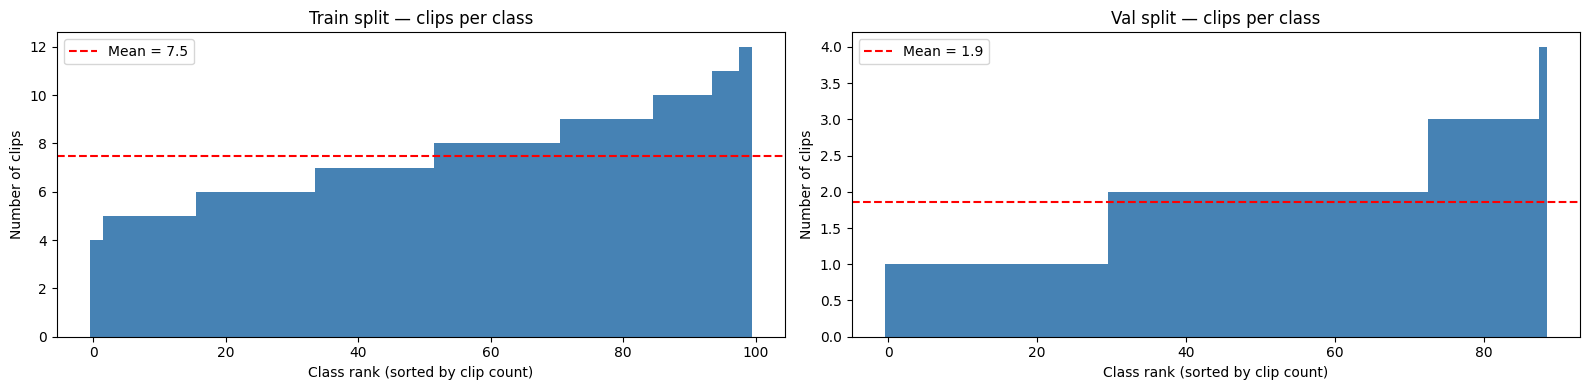

Train clips per class → min: 4  max: 12  mean: 7.5


In [8]:
# ── 6a. Class distribution per split ──────────────────────────────────────
train_labels = [s['label'] for s in train_samples]
val_labels   = [s['label'] for s in val_samples]
test_labels  = [s['label'] for s in test_samples]

train_counts = Counter(train_labels)
val_counts   = Counter(val_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, counts, title in zip(axes,
                              [train_counts, val_counts],
                              ['Train split — clips per class',
                               'Val split — clips per class']):
    sorted_counts = sorted(counts.values())
    ax.bar(range(len(sorted_counts)), sorted_counts, color='steelblue', width=1.0)
    ax.set_title(title)
    ax.set_xlabel('Class rank (sorted by clip count)')
    ax.set_ylabel('Number of clips')
    ax.axhline(np.mean(sorted_counts), color='red', linestyle='--',
               label=f'Mean = {np.mean(sorted_counts):.1f}')
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=120)
plt.show()

print(f'Train clips per class → min: {min(train_counts.values())}  '
      f'max: {max(train_counts.values())}  '
      f'mean: {np.mean(list(train_counts.values())):.1f}')

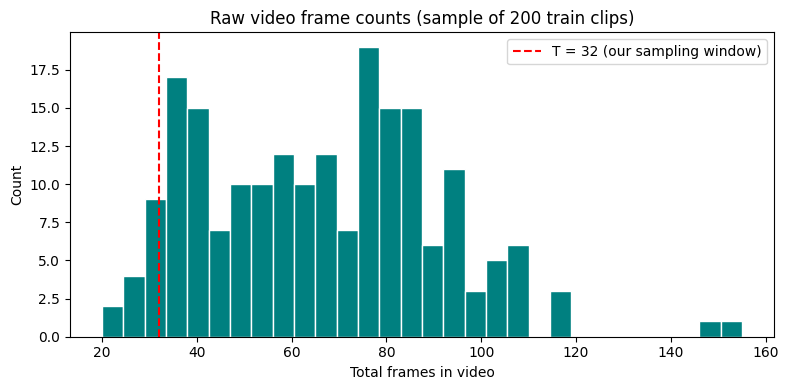

Frame count stats (n=200 sample):
  Min    : 20
  Max    : 155
  Median : 66
  Mean   : 66.1
  Clips shorter than T=32: 10 (5.0%)


In [9]:
# ── 6b. Raw clip length distribution (actual frame counts on disk) ─────────
# Sample 200 random train videos to estimate lengths (checking all is slow)
sample_subset = random.sample(train_samples, min(200, len(train_samples)))
clip_lengths  = []

for s in sample_subset:
    cap = cv2.VideoCapture(s['video_path'])
    if cap.isOpened():
        n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        clip_lengths.append(n)
    cap.release()

plt.figure(figsize=(8, 4))
plt.hist(clip_lengths, bins=30, color='teal', edgecolor='white')
plt.axvline(NUM_FRAMES, color='red', linestyle='--',
            label=f'T = {NUM_FRAMES} (our sampling window)')
plt.title('Raw video frame counts (sample of 200 train clips)')
plt.xlabel('Total frames in video')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clip_length_distribution.png', dpi=120)
plt.show()

print(f'Frame count stats (n=200 sample):')
print(f'  Min    : {min(clip_lengths)}')
print(f'  Max    : {max(clip_lengths)}')
print(f'  Median : {int(np.median(clip_lengths))}')
print(f'  Mean   : {np.mean(clip_lengths):.1f}')
print(f'  Clips shorter than T={NUM_FRAMES}: {sum(l < NUM_FRAMES for l in clip_lengths)} '
      f'({100*sum(l < NUM_FRAMES for l in clip_lengths)/len(clip_lengths):.1f}%)')

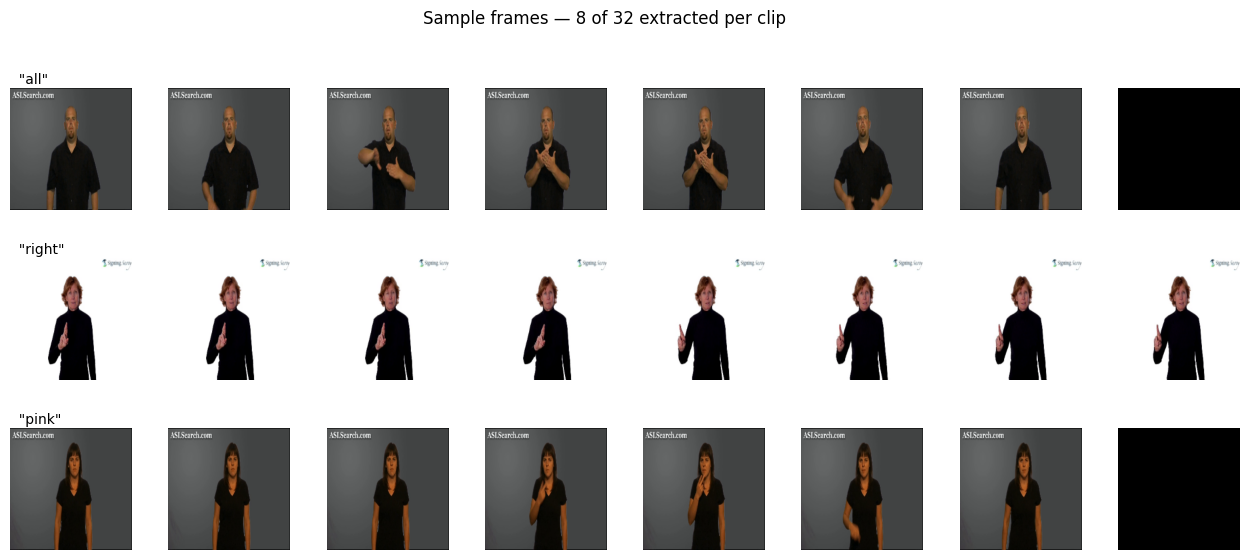

Frame visualization saved.


In [10]:
# ── 6c. Visualize sampled frames from 3 different words ───────────────────
words_to_show = random.sample(all_glosses, 3)

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(3, 8, figure=fig, hspace=0.4)

for row, word in enumerate(words_to_show):
    # Find a train sample for this word
    word_samples = [s for s in train_samples if s['gloss'] == word]
    if not word_samples:
        continue
    s    = word_samples[0]
    clip = load_video_frames(s['video_path'], s['frame_start'], s['frame_end'])
    if clip is None:
        continue

    # Show 8 evenly spaced frames from the 32-frame clip
    frame_indices = np.linspace(0, NUM_FRAMES - 1, 8, dtype=int)
    for col, fi in enumerate(frame_indices):
        ax = fig.add_subplot(gs[row, col])
        # clip is (T, 3, H, W) → convert to (H, W, 3) for matplotlib
        img = np.transpose(clip[fi], (1, 2, 0))
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_title(f'  "{word}"', fontsize=10, loc='left', pad=3)

plt.suptitle('Sample frames — 8 of 32 extracted per clip', y=1.01)
plt.savefig(OUTPUT_DIR / 'sample_frames.png', dpi=120, bbox_inches='tight')
plt.show()
print('Frame visualization saved.')

## Step 7 — Save sample lists for the team
Serialize the split lists to JSON so M3/M4 can rebuild datasets
without re-running the parsing logic.

In [11]:
splits = {
    'train' : train_samples,
    'val'   : val_samples,
    'test'  : test_samples,
}

with open(OUTPUT_DIR / 'splits.json', 'w') as f:
    json.dump(splits, f)

print(f'splits.json saved → {OUTPUT_DIR}/splits.json')
print(f'  Keys: train ({len(train_samples)}), val ({len(val_samples)}), test ({len(test_samples)})')
print(f'\nFiles delivered to team:')
for fname in ['label_map.json', 'splits.json',
              'class_distribution.png', 'clip_length_distribution.png',
              'sample_frames.png']:
    fpath = OUTPUT_DIR / fname
    status = '✓' if fpath.exists() else '✗'
    print(f'  {status}  outputs/{fname}')

splits.json saved → outputs/splits.json
  Keys: train (748), val (165), test (100)

Files delivered to team:
  ✓  outputs/label_map.json
  ✓  outputs/splits.json
  ✓  outputs/class_distribution.png
  ✓  outputs/clip_length_distribution.png
  ✓  outputs/sample_frames.png


## Summary — what M3 needs to import from this notebook

Copy these lines at the top of M3's notebook:

```python
import json
from torch.utils.data import DataLoader

# Load label map
with open('outputs/label_map.json') as f:
    label_map   = json.load(f)
    word_to_idx = label_map['word_to_idx']
    idx_to_word = {int(k): v for k, v in label_map['idx_to_word'].items()}

# Load split lists
with open('outputs/splits.json') as f:
    splits = json.load(f)

# Rebuild datasets
# (copy the WLASLDataset class and load_video_frames function here,
#  or import them from a shared utils.py)
train_loader = DataLoader(WLASLDataset(splits['train']), batch_size=8, shuffle=True)
val_loader   = DataLoader(WLASLDataset(splits['val']),   batch_size=8, shuffle=False)
```

**Each batch from the loader has shape:**
- `frames : (B, 32, 3, 224, 224)` — float32, values in [0, 1]
- `labels : (B,)` — int64 class indices